# Group versus isolated behavioural syllable analysis

This notebook compares behavioural syllables in two ways:

1. **Separate experiments:** group-housed versus socially-isolated CSVs.
2. **Mixed experiment:** grouped+isolated CSV, split by `track_id` into prior social experience (`0-4 = iso`, `5-9 = group`).

Important distinction throughout:

- **Frame-based plots** show how much time animals spend in each behaviour.
- **Initiation-based plots** show how often a behaviour starts. A 30-frame bout counts as **one initiation**, not 30.
- **Bout-duration plots** show how long each continuous behaviour run lasts.

In [1]:
# 1. Imports, style, and analysis settings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

sns.set_theme(style='whitegrid', context='notebook')

FPS = 30  # used only to convert bout length from frames to seconds
MIN_NEIGHBOUR_DISTANCE = 1
MAX_NEIGHBOUR_DISTANCE = 20

condition_order = ['grouped', 'isolated']
social_order = ['group', 'iso']
palette_condition = {'grouped': '#276FBF', 'isolated': '#D1495B'}
palette_social = {'group': '#276FBF', 'iso': '#D1495B'}

base_path = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10'

grouped_path = f'{base_path}/group-housed/behaviour_detection.csv'
isolated_path = f'{base_path}/socially-isolated/behaviour_detection.csv'
mixed_path = f'{base_path}/grouped+isolated/behaviour_detection.csv'

In [2]:
# 2. Load separate grouped and isolated experiments
df_grouped = pd.read_csv(grouped_path)
df_grouped['condition'] = 'grouped'

df_isolated = pd.read_csv(isolated_path)
df_isolated['condition'] = 'isolated'

df_condition = pd.concat([df_grouped, df_isolated], ignore_index=True)

df_condition['file'] = df_condition['file'].astype(str)
df_condition['track_id'] = df_condition['track_id'].astype(int)
df_condition['frame'] = df_condition['frame'].astype(int)

df_condition = df_condition.sort_values(['file', 'track_id', 'frame']).copy()
df_condition['prev_behaviour'] = df_condition.groupby(['file', 'track_id'])['behaviour'].shift()
df_condition['is_initiation'] = df_condition['prev_behaviour'].notna() & (df_condition['behaviour'] != df_condition['prev_behaviour'])
df_condition['new_bout'] = df_condition['prev_behaviour'].isna() | (df_condition['behaviour'] != df_condition['prev_behaviour'])
df_condition['bout_id'] = df_condition.groupby(['file', 'track_id'])['new_bout'].cumsum()

print('Separate grouped/isolated data')
print('Rows:', len(df_condition))
print('Files:', df_condition['file'].nunique())
print('Tracks:', df_condition[['file', 'track_id']].drop_duplicates().shape[0])
print('\nBehaviours:')
print(sorted(df_condition['behaviour'].dropna().unique()))

Separate grouped/isolated data
Rows: 710790
Files: 20
Tracks: 200

Behaviours:
['backward', 'casting', 'digging', 'forward_run', 'hunching', 'sharp_turn', 'small_turn', 'stationary', 'steering', 'turn']


In [3]:
# 3. Load mixed grouped+isolated experiment and split by social experience
df_mixed = pd.read_csv(mixed_path)

df_mixed['file'] = df_mixed['file'].astype(str)
df_mixed['track_id'] = df_mixed['track_id'].astype(int)
df_mixed['frame'] = df_mixed['frame'].astype(int)

df_mixed['social_experience'] = pd.NA
df_mixed.loc[df_mixed['track_id'].between(0, 4), 'social_experience'] = 'iso'
df_mixed.loc[df_mixed['track_id'].between(5, 9), 'social_experience'] = 'group'

df_mixed = df_mixed.dropna(subset=['social_experience']).copy()
df_mixed = df_mixed.sort_values(['file', 'track_id', 'frame']).copy()
df_mixed['prev_behaviour'] = df_mixed.groupby(['file', 'track_id'])['behaviour'].shift()
df_mixed['is_initiation'] = df_mixed['prev_behaviour'].notna() & (df_mixed['behaviour'] != df_mixed['prev_behaviour'])
df_mixed['new_bout'] = df_mixed['prev_behaviour'].isna() | (df_mixed['behaviour'] != df_mixed['prev_behaviour'])
df_mixed['bout_id'] = df_mixed.groupby(['file', 'track_id'])['new_bout'].cumsum()

print('Mixed grouped+isolated data')
print('Rows:', len(df_mixed))
print('Files:', df_mixed['file'].nunique())
print('Tracks:', df_mixed[['file', 'track_id']].drop_duplicates().shape[0])
print('\nTrack IDs by assigned social experience:')
print(df_mixed.groupby('social_experience')['track_id'].unique())

Mixed grouped+isolated data
Rows: 425693
Files: 12
Tracks: 120

Track IDs by assigned social experience:
social_experience
group    [5, 6, 7, 8, 9]
iso      [0, 1, 2, 3, 4]
Name: track_id, dtype: object


In [4]:
# 4. Behaviour order used in the plots
behaviour_order = (
    df_condition['behaviour']
    .value_counts()
    .index
    .tolist()
)

print(behaviour_order)

['forward_run', 'stationary', 'turn', 'sharp_turn', 'digging', 'steering', 'backward', 'small_turn', 'hunching', 'casting']


## Separate Experiments: Group-Housed versus Socially-Isolated

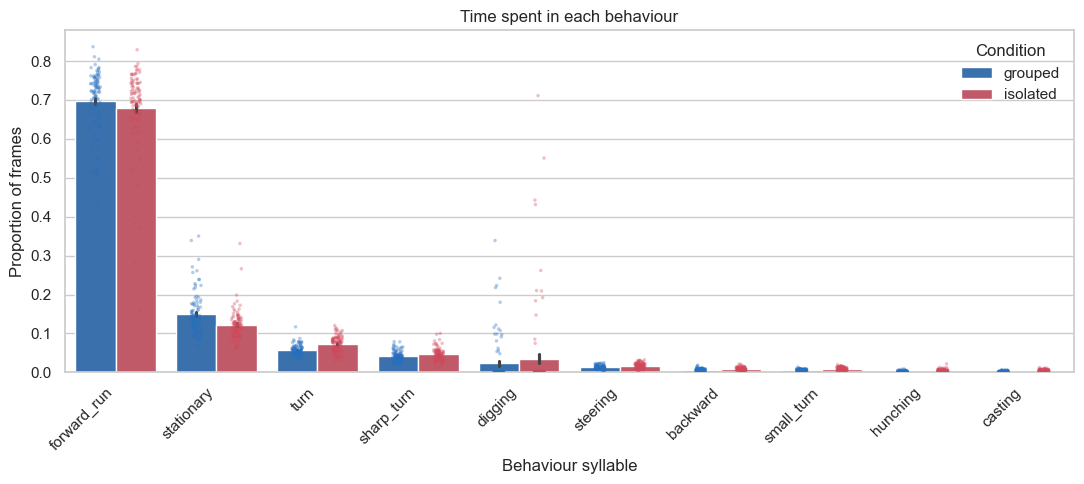

In [5]:
# 5. Time spent in each behaviour: frame-based proportion per animal
# This answers: what fraction of frames is each animal spending in each syllable?
total_frames_condition = (
    df_condition
    .groupby(['condition', 'file', 'track_id'])
    .size()
    .reset_index(name='total_frames')
)

behaviour_frames_condition = (
    df_condition
    .groupby(['condition', 'file', 'track_id', 'behaviour'])
    .size()
    .reset_index(name='n_frames')
)

# add explicit zeros so animals with no frames for a behaviour still contribute
animal_behaviour_grid_condition = total_frames_condition.assign(key=1).merge(
    pd.DataFrame({'behaviour': behaviour_order, 'key': 1}),
    on='key'
).drop(columns='key')

behaviour_prop_condition = animal_behaviour_grid_condition.merge(
    behaviour_frames_condition,
    on=['condition', 'file', 'track_id', 'behaviour'],
    how='left'
)
behaviour_prop_condition['n_frames'] = behaviour_prop_condition['n_frames'].fillna(0)
behaviour_prop_condition['proportion_of_frames'] = behaviour_prop_condition['n_frames'] / behaviour_prop_condition['total_frames']

plt.figure(figsize=(11, 5))
sns.barplot(
    data=behaviour_prop_condition,
    x='behaviour',
    y='proportion_of_frames',
    hue='condition',
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette_condition,
    errorbar='se'
)
sns.stripplot(
    data=behaviour_prop_condition,
    x='behaviour',
    y='proportion_of_frames',
    hue='condition',
    order=behaviour_order,
    hue_order=condition_order,
    dodge=True,
    palette=palette_condition,
    alpha=0.35,
    size=2.5,
    legend=False
)
plt.ylim(0, None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Proportion of frames')
plt.title('Time spent in each behaviour')
plt.legend(title='Condition', frameon=False)
plt.tight_layout()
plt.show()

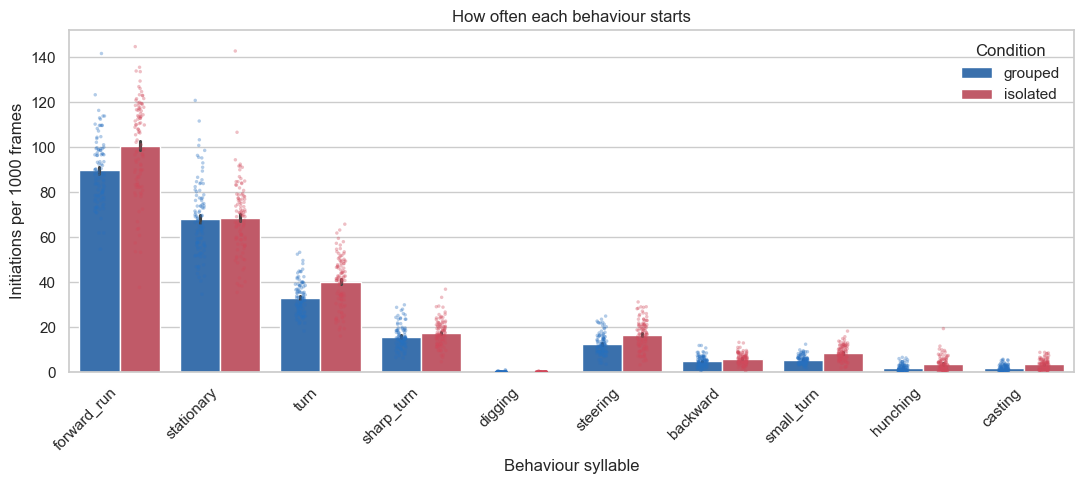

In [6]:
# 6. Behaviour starts: initiation rate per 1000 frames
# This answers: how often does each behaviour begin, regardless of how long it lasts?
initiation_counts_condition = (
    df_condition[df_condition['is_initiation']]
    .groupby(['condition', 'file', 'track_id', 'behaviour'])
    .size()
    .reset_index(name='n_initiations')
)

initiation_rate_condition = animal_behaviour_grid_condition.merge(
    initiation_counts_condition,
    on=['condition', 'file', 'track_id', 'behaviour'],
    how='left'
)
initiation_rate_condition['n_initiations'] = initiation_rate_condition['n_initiations'].fillna(0)
initiation_rate_condition['initiations_per_1000_frames'] = initiation_rate_condition['n_initiations'] / initiation_rate_condition['total_frames'] * 1000

plt.figure(figsize=(11, 5))
sns.barplot(
    data=initiation_rate_condition,
    x='behaviour',
    y='initiations_per_1000_frames',
    hue='condition',
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette_condition,
    errorbar='se'
)
sns.stripplot(
    data=initiation_rate_condition,
    x='behaviour',
    y='initiations_per_1000_frames',
    hue='condition',
    order=behaviour_order,
    hue_order=condition_order,
    dodge=True,
    palette=palette_condition,
    alpha=0.35,
    size=2.5,
    legend=False
)
plt.ylim(0, None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Initiations per 1000 frames')
plt.title('How often each behaviour starts')
plt.legend(title='Condition', frameon=False)
plt.tight_layout()
plt.show()

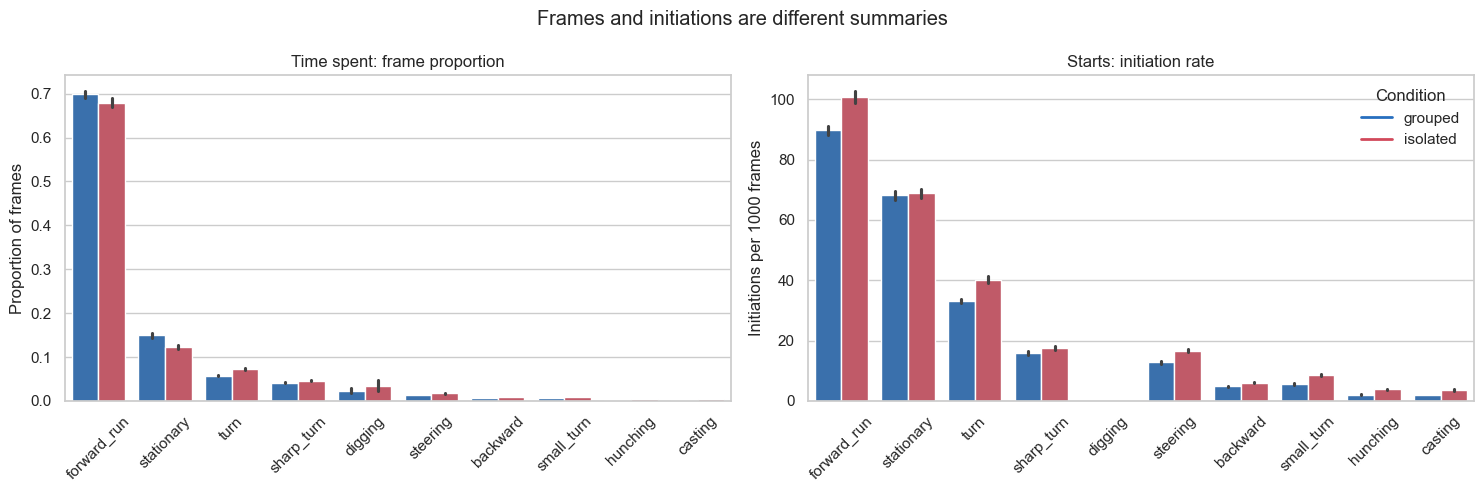

In [7]:
# 7. Frame proportion versus initiation rate shown side-by-side
# Useful for spotting behaviours that are rare but long, or frequent but brief.
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

sns.barplot(
    data=behaviour_prop_condition,
    x='behaviour',
    y='proportion_of_frames',
    hue='condition',
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette_condition,
    errorbar='se',
    ax=axes[0]
)
axes[0].set_title('Time spent: frame proportion')
axes[0].set_xlabel('')
axes[0].set_ylabel('Proportion of frames')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend_.remove()

sns.barplot(
    data=initiation_rate_condition,
    x='behaviour',
    y='initiations_per_1000_frames',
    hue='condition',
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette_condition,
    errorbar='se',
    ax=axes[1]
)
axes[1].set_title('Starts: initiation rate')
axes[1].set_xlabel('')
axes[1].set_ylabel('Initiations per 1000 frames')
axes[1].tick_params(axis='x', rotation=45)
condition_handles = [
    mpl.lines.Line2D([0], [0], color=palette_condition[name], lw=2, label=name)
    for name in condition_order
]
axes[1].legend(handles=condition_handles, title='Condition', frameon=False)

plt.suptitle('Frames and initiations are different summaries')
plt.tight_layout()
plt.show()

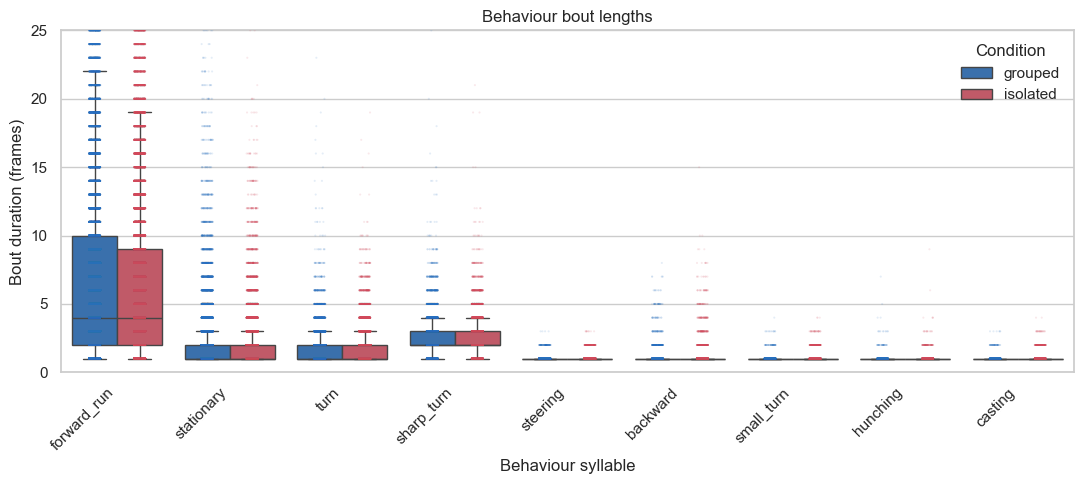

In [8]:
# 8. Bout duration: how long each continuous behaviour run lasts
bouts_condition = (
    df_condition
    .groupby(['condition', 'file', 'track_id', 'bout_id', 'behaviour'])
    .agg(
        start_frame=('frame', 'min'),
        end_frame=('frame', 'max'),
        n_frames=('frame', 'count')
    )
    .reset_index()
)
bouts_condition['duration_seconds'] = bouts_condition['n_frames'] / FPS

bouts_condition_plot = bouts_condition[bouts_condition['behaviour'] != 'digging'].copy()

plt.figure(figsize=(11, 5))
sns.boxplot(
    data=bouts_condition_plot,
    x='behaviour',
    y='n_frames',
    hue='condition',
    order=[b for b in behaviour_order if b != 'digging'],
    hue_order=condition_order,
    palette=palette_condition,
    showfliers=False
)
sns.stripplot(
    data=bouts_condition_plot,
    x='behaviour',
    y='n_frames',
    hue='condition',
    order=[b for b in behaviour_order if b != 'digging'],
    hue_order=condition_order,
    dodge=True,
    palette=palette_condition,
    alpha=0.12,
    size=1.5,
    legend=False
)
plt.ylim(0, bouts_condition_plot['n_frames'].quantile(0.98))
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Bout duration (frames)')
plt.title('Behaviour bout lengths')
plt.legend(title='Condition', frameon=False)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39946/4164056611.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


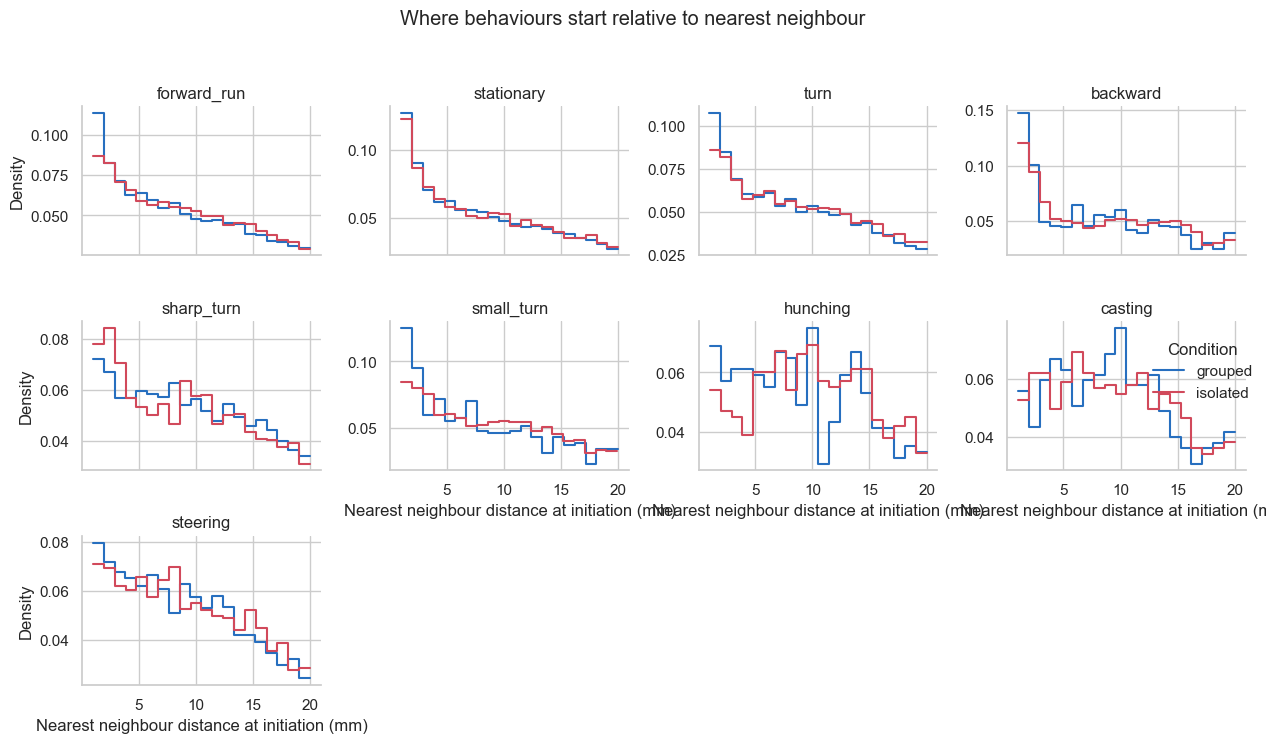

In [9]:
# 9. Initiation distance to nearest neighbour, split by behaviour
# Only initiation frames are used here, so a long bout contributes once.
init_distance_condition = df_condition[
    df_condition['is_initiation'] &
    df_condition['closest_node_node_distance'].notna() &
    (df_condition['closest_node_node_distance'] >= MIN_NEIGHBOUR_DISTANCE) &
    (df_condition['closest_node_node_distance'] <= MAX_NEIGHBOUR_DISTANCE) &
    (df_condition['behaviour'] != 'digging')
].copy()

g = sns.FacetGrid(
    init_distance_condition,
    col='behaviour',
    col_wrap=4,
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    sharex=True,
    sharey=False,
    height=2.4,
    aspect=1.2
)
g.map_dataframe(
    sns.histplot,
    x='closest_node_node_distance',
    bins=20,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    linewidth=1.5
)
g.add_legend(title='Condition')
g.set_axis_labels('Nearest neighbour distance at initiation (mm)', 'Density')
g.set_titles('{col_name}')
g.figure.suptitle('Where behaviours start relative to nearest neighbour', y=1.03)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39946/4218033396.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


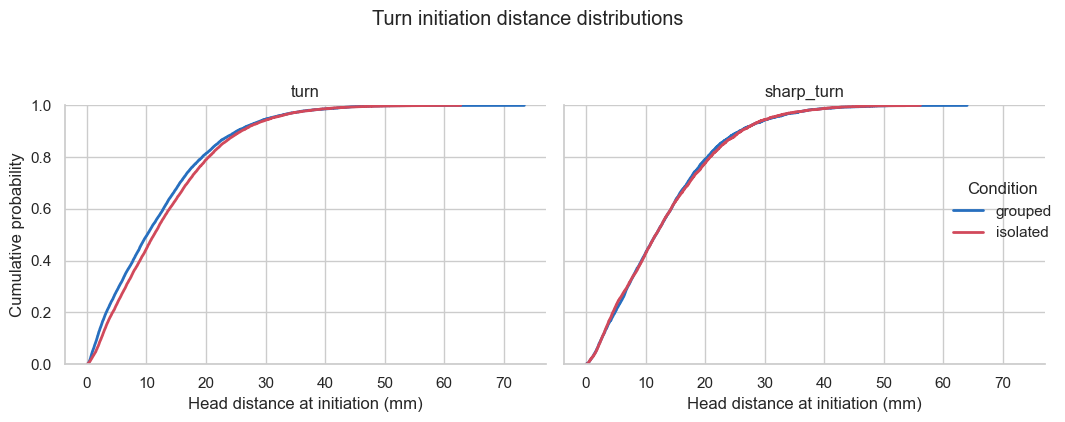

In [10]:
# 10. Head-to-head distance at turn and sharp-turn initiation
turn_init_condition = df_condition[
    df_condition['is_initiation'] &
    df_condition['head_distance'].notna() &
    df_condition['behaviour'].isin(['turn', 'sharp_turn'])
].copy()

g = sns.FacetGrid(
    turn_init_condition,
    col='behaviour',
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    sharex=True,
    sharey=True,
    height=4,
    aspect=1.2
)
g.map_dataframe(
    sns.ecdfplot,
    x='head_distance',
    linewidth=2
)
g.add_legend(title='Condition')
g.set_axis_labels('Head distance at initiation (mm)', 'Cumulative probability')
g.set_titles('{col_name}')
g.figure.suptitle('Turn initiation distance distributions', y=1.05)
plt.tight_layout()
plt.show()

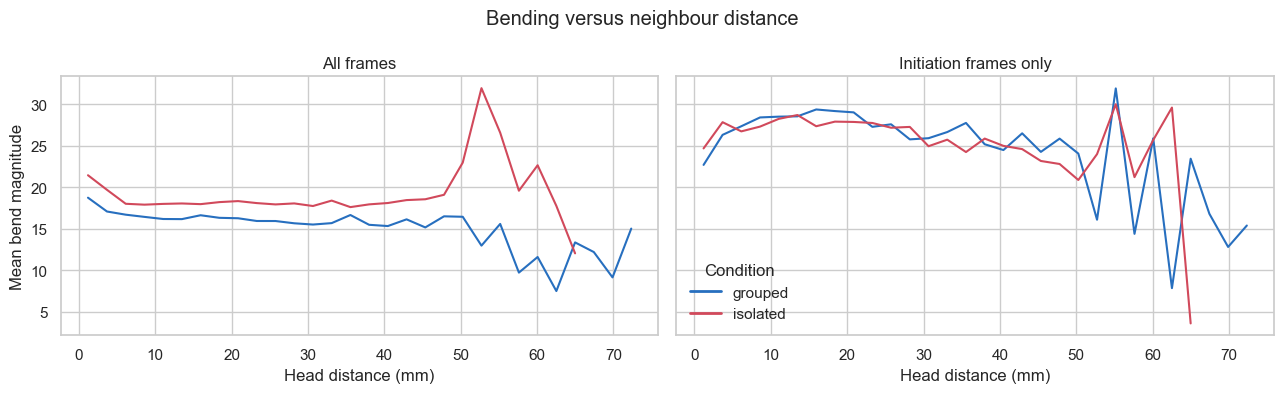

In [11]:
# 11. Bend magnitude by neighbour distance: frame-based and initiation-only
# Left: every valid frame. Right: only behaviour starts.
df_bend_frames = df_condition[
    df_condition['head_distance'].notna() &
    df_condition['bend_magnitude'].notna()
].copy()
df_bend_frames['distance_bin'] = pd.cut(df_bend_frames['head_distance'], bins=30)
df_bend_frames['distance_mid'] = df_bend_frames['distance_bin'].apply(lambda x: x.mid)

binned_bend_frames = (
    df_bend_frames
    .groupby(['distance_mid', 'condition'], observed=True)['bend_magnitude']
    .mean()
    .reset_index()
)

df_bend_init = df_bend_frames[df_bend_frames['is_initiation']].copy()
binned_bend_init = (
    df_bend_init
    .groupby(['distance_mid', 'condition'], observed=True)['bend_magnitude']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

sns.lineplot(
    data=binned_bend_frames,
    x='distance_mid',
    y='bend_magnitude',
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    ax=axes[0]
)
axes[0].set_title('All frames')
axes[0].set_xlabel('Head distance (mm)')
axes[0].set_ylabel('Mean bend magnitude')
axes[0].legend_.remove()

sns.lineplot(
    data=binned_bend_init,
    x='distance_mid',
    y='bend_magnitude',
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    ax=axes[1]
)
axes[1].set_title('Initiation frames only')
axes[1].set_xlabel('Head distance (mm)')
axes[1].set_ylabel('')
condition_handles = [
    mpl.lines.Line2D([0], [0], color=palette_condition[name], lw=2, label=name)
    for name in condition_order
]
axes[1].legend(handles=condition_handles, title='Condition', frameon=False)

plt.suptitle('Bending versus neighbour distance')
plt.tight_layout()
plt.show()

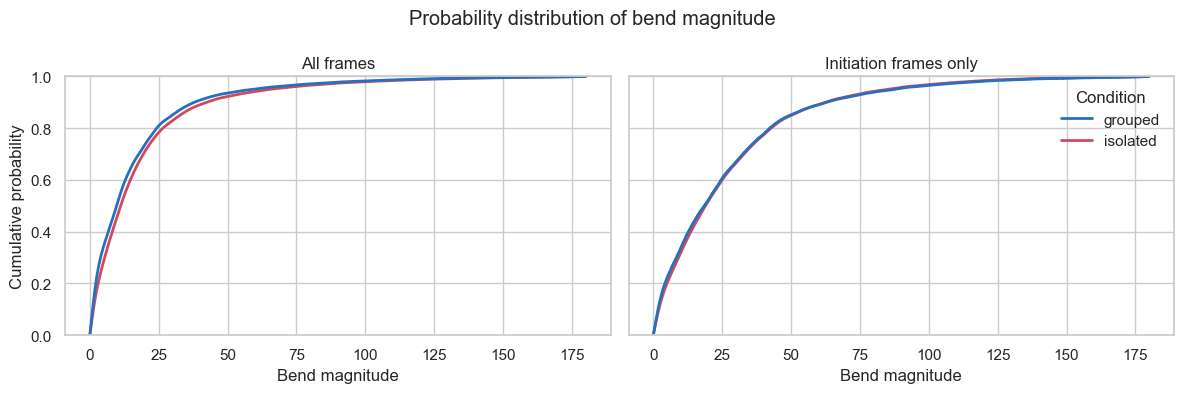

In [12]:
# 12. Bend magnitude probability curves: all frames versus initiation frames
# ECDF plots: y is cumulative probability, x is bend magnitude.
# Left uses every frame. Right only uses frames where a new behaviour starts.
bend_prob_condition = df_condition[df_condition['bend_magnitude'].notna()].copy()
bend_prob_condition_init = bend_prob_condition[bend_prob_condition['is_initiation']].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

sns.ecdfplot(
    data=bend_prob_condition,
    x='bend_magnitude',
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('All frames')
axes[0].set_xlabel('Bend magnitude')
axes[0].set_ylabel('Cumulative probability')
axes[0].legend_.remove()

sns.ecdfplot(
    data=bend_prob_condition_init,
    x='bend_magnitude',
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title('Initiation frames only')
axes[1].set_xlabel('Bend magnitude')
axes[1].set_ylabel('')
condition_handles = [
    mpl.lines.Line2D([0], [0], color=palette_condition[name], lw=2, label=name)
    for name in condition_order
]
axes[1].legend(handles=condition_handles, title='Condition', frameon=False)

plt.suptitle('Probability distribution of bend magnitude')
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39946/2654496760.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


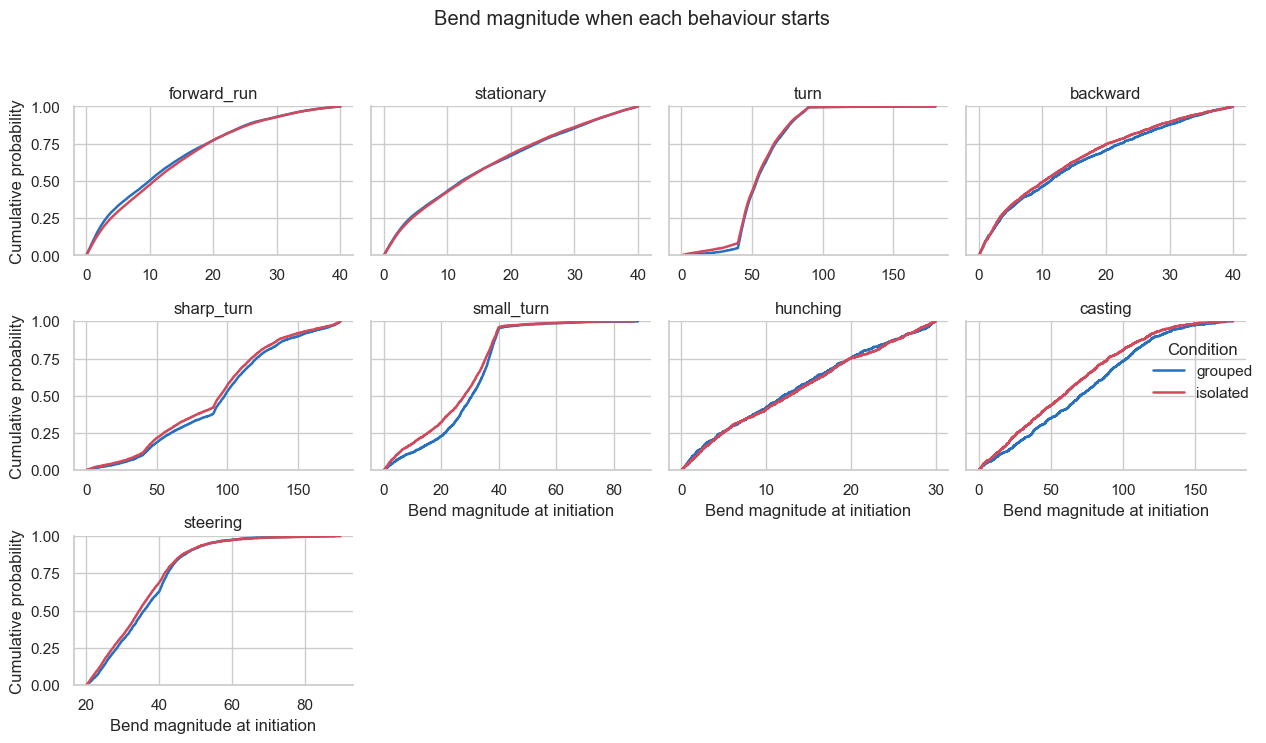

In [13]:
# 13. Bend magnitude probability curves by behaviour, initiation frames only
# Each continuous behaviour bout contributes only its first frame here.
bend_prob_condition_by_behaviour = df_condition[
    df_condition['is_initiation'] &
    df_condition['bend_magnitude'].notna() &
    (df_condition['behaviour'] != 'digging')
].copy()

g = sns.FacetGrid(
    bend_prob_condition_by_behaviour,
    col='behaviour',
    col_wrap=4,
    hue='condition',
    hue_order=condition_order,
    palette=palette_condition,
    sharex=False,
    sharey=True,
    height=2.4,
    aspect=1.2
)
g.map_dataframe(
    sns.ecdfplot,
    x='bend_magnitude',
    linewidth=1.8
)
g.add_legend(title='Condition')
g.set_axis_labels('Bend magnitude at initiation', 'Cumulative probability')
g.set_titles('{col_name}')
g.figure.suptitle('Bend magnitude when each behaviour starts', y=1.03)
plt.tight_layout()
plt.show()

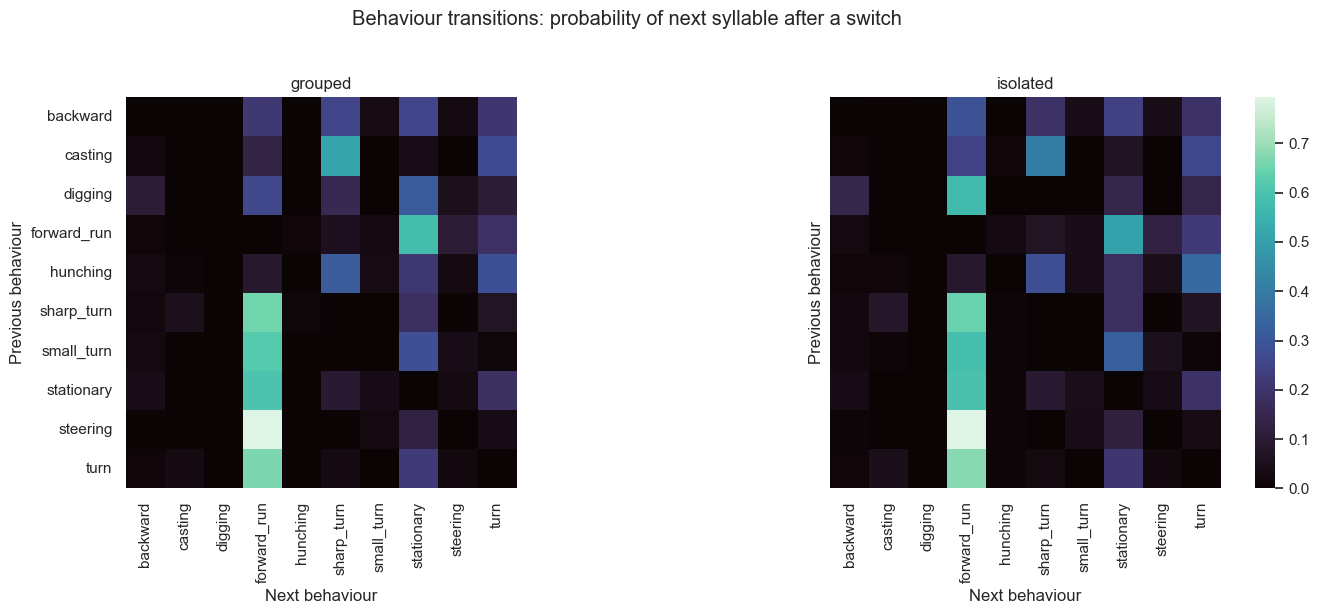

In [14]:
# 14. Behaviour transition matrices
# Rows are previous behaviour, columns are next behaviour. Each row sums to 1.
df_trans_condition = df_condition[
    df_condition['prev_behaviour'].notna() &
    (df_condition['behaviour'] != df_condition['prev_behaviour'])
].copy()

all_behaviours = sorted(set(df_trans_condition['prev_behaviour']).union(set(df_trans_condition['behaviour'])))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

transition_mats_condition = {}
for ax, condition in zip(axes, condition_order):
    mat = pd.crosstab(
        df_trans_condition.loc[df_trans_condition['condition'] == condition, 'prev_behaviour'],
        df_trans_condition.loc[df_trans_condition['condition'] == condition, 'behaviour'],
        normalize='index'
    )
    mat = mat.reindex(index=all_behaviours, columns=all_behaviours).fillna(0)
    transition_mats_condition[condition] = mat

    sns.heatmap(
        mat,
        ax=ax,
        cmap='mako',
        vmin=0,
        vmax=max(0.01, mat.to_numpy().max()),
        square=True,
        cbar=ax == axes[-1]
    )
    ax.set_title(condition)
    ax.set_xlabel('Next behaviour')
    ax.set_ylabel('Previous behaviour')

plt.suptitle('Behaviour transitions: probability of next syllable after a switch', y=1.02)
plt.tight_layout()
plt.show()

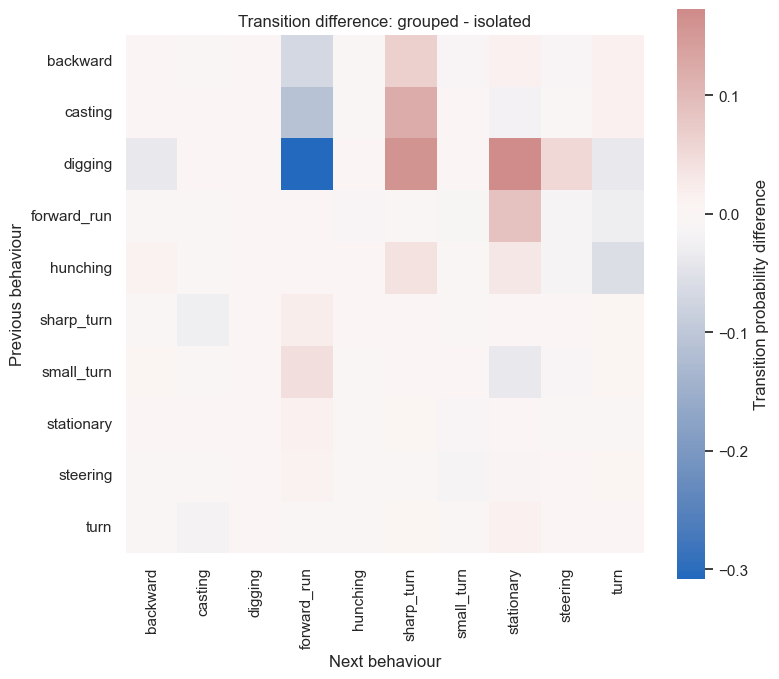

In [15]:
# 15. Transition difference: grouped minus isolated
# Blue means more likely after grouped housing; red means more likely after isolation.
transition_difference = transition_mats_condition['grouped'] - transition_mats_condition['isolated']

plt.figure(figsize=(8, 7))
sns.heatmap(
    transition_difference,
    cmap='vlag',
    center=0,
    square=True,
    cbar_kws={'label': 'Transition probability difference'}
)
plt.xlabel('Next behaviour')
plt.ylabel('Previous behaviour')
plt.title('Transition difference: grouped - isolated')
plt.tight_layout()
plt.show()

## Mixed Experiment: Prior Group versus Prior Iso Animals in the Same Arena

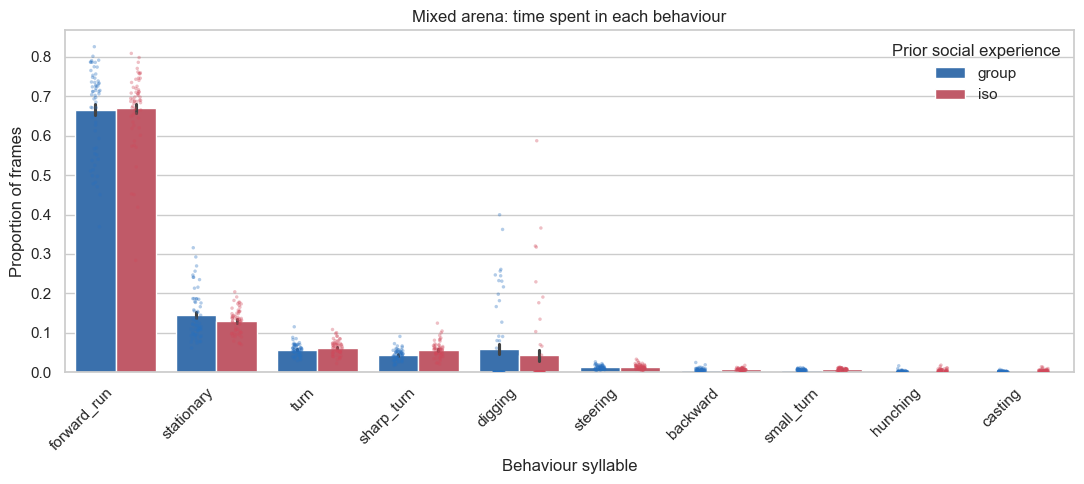

In [16]:
# 16. Mixed experiment: time spent in each behaviour by prior social experience
total_frames_mixed = (
    df_mixed
    .groupby(['social_experience', 'file', 'track_id'])
    .size()
    .reset_index(name='total_frames')
)

behaviour_frames_mixed = (
    df_mixed
    .groupby(['social_experience', 'file', 'track_id', 'behaviour'])
    .size()
    .reset_index(name='n_frames')
)

# add explicit zeros so animals with no frames for a behaviour still contribute
animal_behaviour_grid_mixed = total_frames_mixed.assign(key=1).merge(
    pd.DataFrame({'behaviour': behaviour_order, 'key': 1}),
    on='key'
).drop(columns='key')

behaviour_prop_mixed = animal_behaviour_grid_mixed.merge(
    behaviour_frames_mixed,
    on=['social_experience', 'file', 'track_id', 'behaviour'],
    how='left'
)
behaviour_prop_mixed['n_frames'] = behaviour_prop_mixed['n_frames'].fillna(0)
behaviour_prop_mixed['proportion_of_frames'] = behaviour_prop_mixed['n_frames'] / behaviour_prop_mixed['total_frames']

plt.figure(figsize=(11, 5))
sns.barplot(
    data=behaviour_prop_mixed,
    x='behaviour',
    y='proportion_of_frames',
    hue='social_experience',
    order=behaviour_order,
    hue_order=social_order,
    palette=palette_social,
    errorbar='se'
)
sns.stripplot(
    data=behaviour_prop_mixed,
    x='behaviour',
    y='proportion_of_frames',
    hue='social_experience',
    order=behaviour_order,
    hue_order=social_order,
    dodge=True,
    palette=palette_social,
    alpha=0.35,
    size=2.5,
    legend=False
)
plt.ylim(0, None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Proportion of frames')
plt.title('Mixed arena: time spent in each behaviour')
plt.legend(title='Prior social experience', frameon=False)
plt.tight_layout()
plt.show()

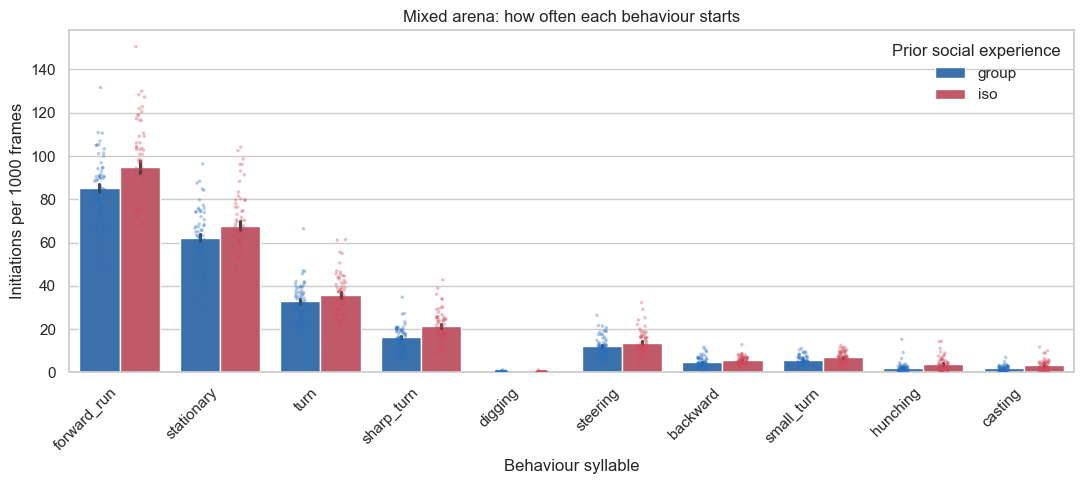

In [17]:
# 17. Mixed experiment: initiation rate by prior social experience
initiation_counts_mixed = (
    df_mixed[df_mixed['is_initiation']]
    .groupby(['social_experience', 'file', 'track_id', 'behaviour'])
    .size()
    .reset_index(name='n_initiations')
)

initiation_rate_mixed = animal_behaviour_grid_mixed.merge(
    initiation_counts_mixed,
    on=['social_experience', 'file', 'track_id', 'behaviour'],
    how='left'
)
initiation_rate_mixed['n_initiations'] = initiation_rate_mixed['n_initiations'].fillna(0)
initiation_rate_mixed['initiations_per_1000_frames'] = initiation_rate_mixed['n_initiations'] / initiation_rate_mixed['total_frames'] * 1000

plt.figure(figsize=(11, 5))
sns.barplot(
    data=initiation_rate_mixed,
    x='behaviour',
    y='initiations_per_1000_frames',
    hue='social_experience',
    order=behaviour_order,
    hue_order=social_order,
    palette=palette_social,
    errorbar='se'
)
sns.stripplot(
    data=initiation_rate_mixed,
    x='behaviour',
    y='initiations_per_1000_frames',
    hue='social_experience',
    order=behaviour_order,
    hue_order=social_order,
    dodge=True,
    palette=palette_social,
    alpha=0.35,
    size=2.5,
    legend=False
)
plt.ylim(0, None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Initiations per 1000 frames')
plt.title('Mixed arena: how often each behaviour starts')
plt.legend(title='Prior social experience', frameon=False)
plt.tight_layout()
plt.show()

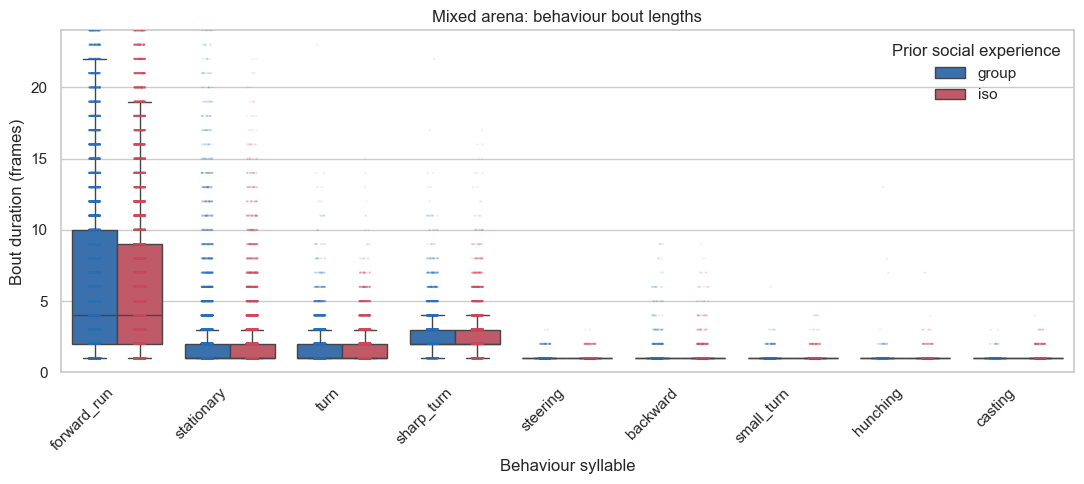

In [18]:
# 18. Mixed experiment: bout lengths by prior social experience
bouts_mixed = (
    df_mixed
    .groupby(['social_experience', 'file', 'track_id', 'bout_id', 'behaviour'])
    .agg(
        start_frame=('frame', 'min'),
        end_frame=('frame', 'max'),
        n_frames=('frame', 'count')
    )
    .reset_index()
)
bouts_mixed['duration_seconds'] = bouts_mixed['n_frames'] / FPS
bouts_mixed_plot = bouts_mixed[bouts_mixed['behaviour'] != 'digging'].copy()

plt.figure(figsize=(11, 5))
sns.boxplot(
    data=bouts_mixed_plot,
    x='behaviour',
    y='n_frames',
    hue='social_experience',
    order=[b for b in behaviour_order if b != 'digging'],
    hue_order=social_order,
    palette=palette_social,
    showfliers=False
)
sns.stripplot(
    data=bouts_mixed_plot,
    x='behaviour',
    y='n_frames',
    hue='social_experience',
    order=[b for b in behaviour_order if b != 'digging'],
    hue_order=social_order,
    dodge=True,
    palette=palette_social,
    alpha=0.12,
    size=1.5,
    legend=False
)
plt.ylim(0, bouts_mixed_plot['n_frames'].quantile(0.98))
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Bout duration (frames)')
plt.title('Mixed arena: behaviour bout lengths')
plt.legend(title='Prior social experience', frameon=False)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39946/3641239779.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


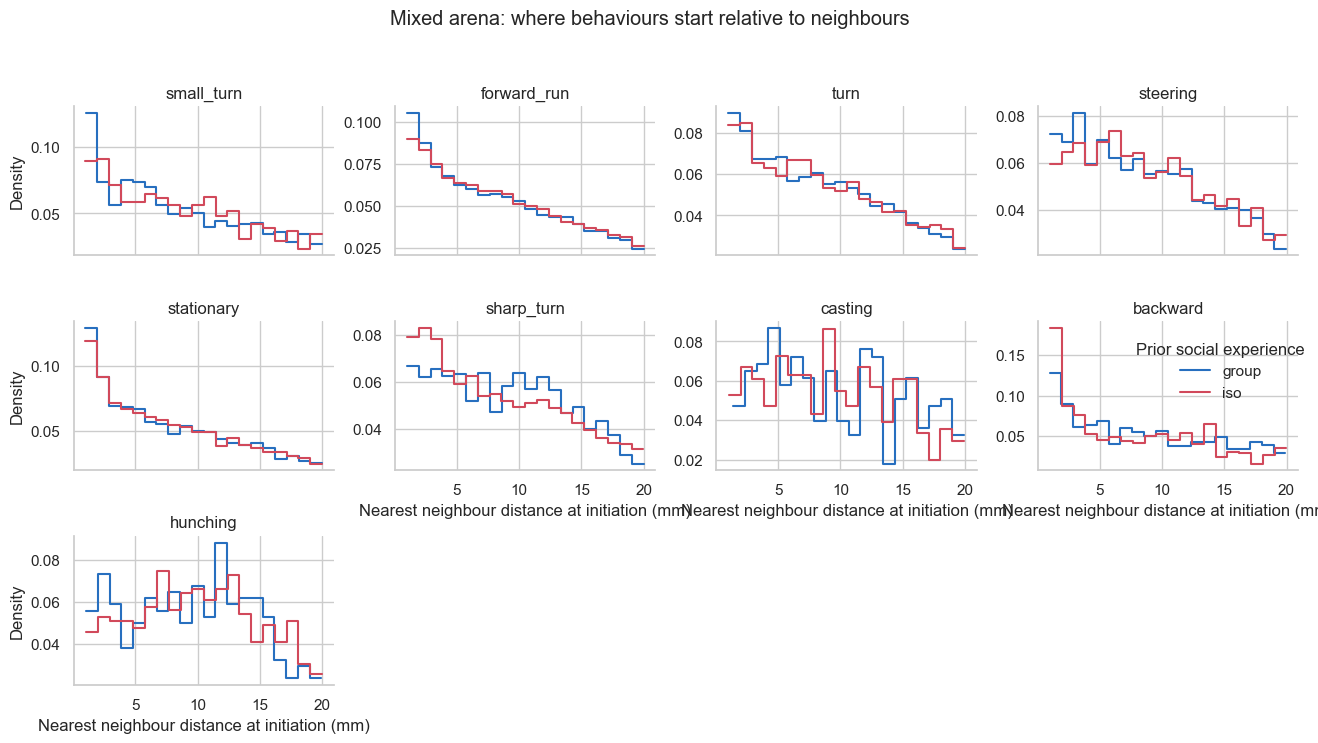

In [19]:
# 19. Mixed experiment: initiation distance to nearest neighbour
init_distance_mixed = df_mixed[
    df_mixed['is_initiation'] &
    df_mixed['closest_node_node_distance'].notna() &
    (df_mixed['closest_node_node_distance'] >= MIN_NEIGHBOUR_DISTANCE) &
    (df_mixed['closest_node_node_distance'] <= MAX_NEIGHBOUR_DISTANCE) &
    (df_mixed['behaviour'] != 'digging')
].copy()

g = sns.FacetGrid(
    init_distance_mixed,
    col='behaviour',
    col_wrap=4,
    hue='social_experience',
    hue_order=social_order,
    palette=palette_social,
    sharex=True,
    sharey=False,
    height=2.4,
    aspect=1.2
)
g.map_dataframe(
    sns.histplot,
    x='closest_node_node_distance',
    bins=20,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    linewidth=1.5
)
g.add_legend(title='Prior social experience')
g.set_axis_labels('Nearest neighbour distance at initiation (mm)', 'Density')
g.set_titles('{col_name}')
g.figure.suptitle('Mixed arena: where behaviours start relative to neighbours', y=1.03)
plt.tight_layout()
plt.show()

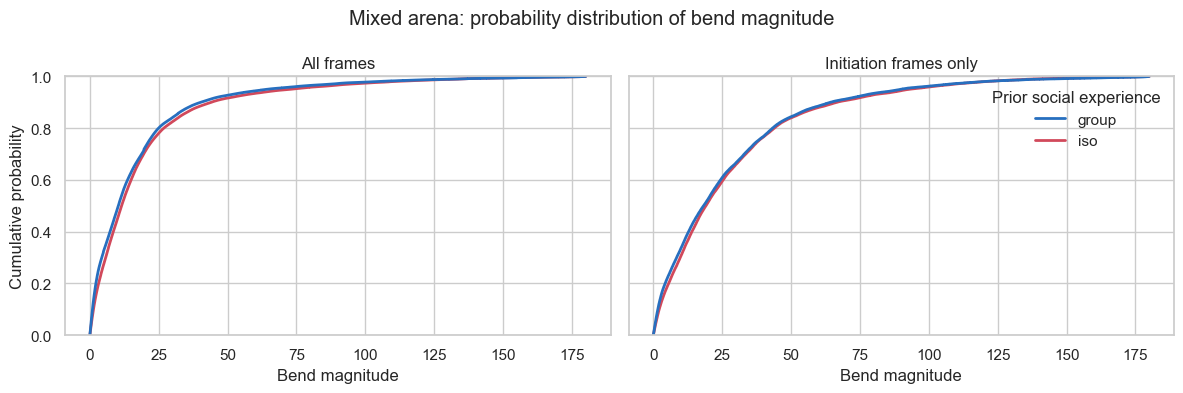

In [20]:
# 20. Mixed experiment: bend magnitude probability curves
# ECDF plots: y is cumulative probability, x is bend magnitude.
# Left uses every frame. Right only uses frames where a new behaviour starts.
bend_prob_mixed = df_mixed[df_mixed['bend_magnitude'].notna()].copy()
bend_prob_mixed_init = bend_prob_mixed[bend_prob_mixed['is_initiation']].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

sns.ecdfplot(
    data=bend_prob_mixed,
    x='bend_magnitude',
    hue='social_experience',
    hue_order=social_order,
    palette=palette_social,
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('All frames')
axes[0].set_xlabel('Bend magnitude')
axes[0].set_ylabel('Cumulative probability')
axes[0].legend_.remove()

sns.ecdfplot(
    data=bend_prob_mixed_init,
    x='bend_magnitude',
    hue='social_experience',
    hue_order=social_order,
    palette=palette_social,
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title('Initiation frames only')
axes[1].set_xlabel('Bend magnitude')
axes[1].set_ylabel('')
social_handles = [
    mpl.lines.Line2D([0], [0], color=palette_social[name], lw=2, label=name)
    for name in social_order
]
axes[1].legend(handles=social_handles, title='Prior social experience', frameon=False)

plt.suptitle('Mixed arena: probability distribution of bend magnitude')
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39946/945683529.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


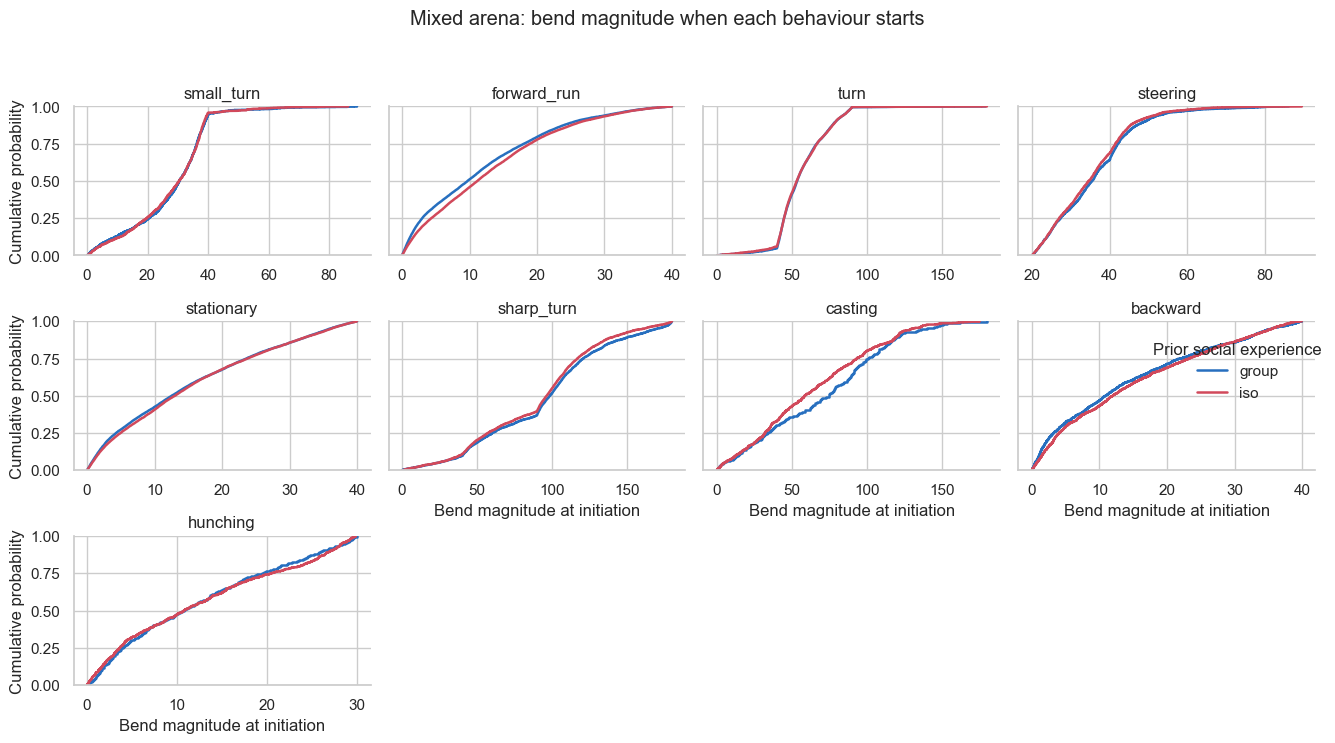

In [21]:
# 21. Mixed experiment: bend magnitude probability curves by behaviour, initiation frames only
# Each continuous behaviour bout contributes only its first frame here.
bend_prob_mixed_by_behaviour = df_mixed[
    df_mixed['is_initiation'] &
    df_mixed['bend_magnitude'].notna() &
    (df_mixed['behaviour'] != 'digging')
].copy()

g = sns.FacetGrid(
    bend_prob_mixed_by_behaviour,
    col='behaviour',
    col_wrap=4,
    hue='social_experience',
    hue_order=social_order,
    palette=palette_social,
    sharex=False,
    sharey=True,
    height=2.4,
    aspect=1.2
)
g.map_dataframe(
    sns.ecdfplot,
    x='bend_magnitude',
    linewidth=1.8
)
g.add_legend(title='Prior social experience')
g.set_axis_labels('Bend magnitude at initiation', 'Cumulative probability')
g.set_titles('{col_name}')
g.figure.suptitle('Mixed arena: bend magnitude when each behaviour starts', y=1.03)
plt.tight_layout()
plt.show()

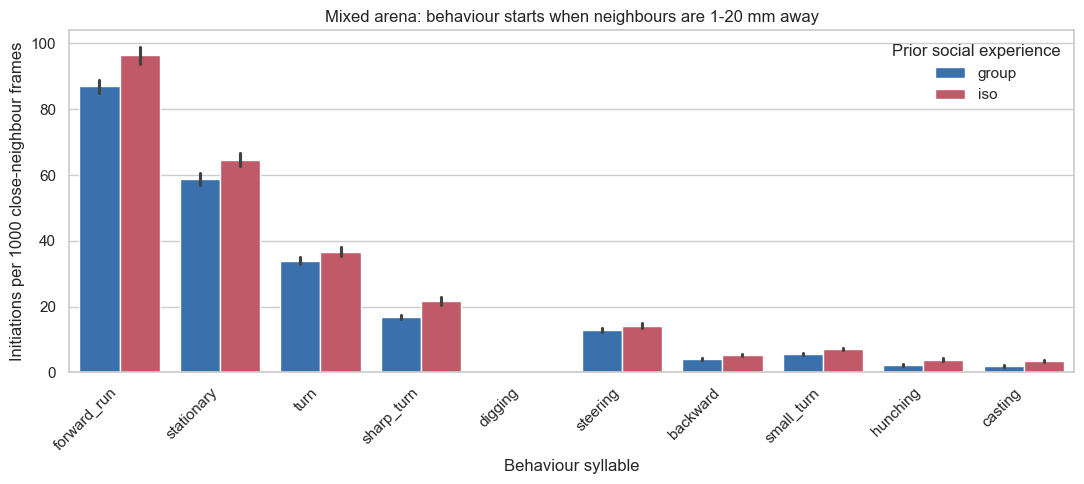

In [22]:
# 22. Mixed experiment: close-neighbour initiation rates
# This only counts starts occurring when larvae are within the chosen distance window.
df_mixed_close = df_mixed[
    df_mixed['closest_node_node_distance'].notna() &
    (df_mixed['closest_node_node_distance'] >= MIN_NEIGHBOUR_DISTANCE) &
    (df_mixed['closest_node_node_distance'] <= MAX_NEIGHBOUR_DISTANCE)
].copy()

close_total_frames_mixed = (
    df_mixed_close
    .groupby(['social_experience', 'file', 'track_id'])
    .size()
    .reset_index(name='close_total_frames')
)

close_initiations_mixed = (
    df_mixed_close[df_mixed_close['is_initiation']]
    .groupby(['social_experience', 'file', 'track_id', 'behaviour'])
    .size()
    .reset_index(name='n_initiations')
)

close_behaviour_grid_mixed = close_total_frames_mixed.assign(key=1).merge(
    pd.DataFrame({'behaviour': behaviour_order, 'key': 1}),
    on='key'
).drop(columns='key')

close_initiation_rate_mixed = close_behaviour_grid_mixed.merge(
    close_initiations_mixed,
    on=['social_experience', 'file', 'track_id', 'behaviour'],
    how='left'
)
close_initiation_rate_mixed['n_initiations'] = close_initiation_rate_mixed['n_initiations'].fillna(0)
close_initiation_rate_mixed['initiations_per_1000_close_frames'] = (
    close_initiation_rate_mixed['n_initiations'] / close_initiation_rate_mixed['close_total_frames'] * 1000
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=close_initiation_rate_mixed,
    x='behaviour',
    y='initiations_per_1000_close_frames',
    hue='social_experience',
    order=behaviour_order,
    hue_order=social_order,
    palette=palette_social,
    errorbar='se'
)
plt.ylim(0, None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Behaviour syllable')
plt.ylabel('Initiations per 1000 close-neighbour frames')
plt.title(f'Mixed arena: behaviour starts when neighbours are {MIN_NEIGHBOUR_DISTANCE}-{MAX_NEIGHBOUR_DISTANCE} mm away')
plt.legend(title='Prior social experience', frameon=False)
plt.tight_layout()
plt.show()

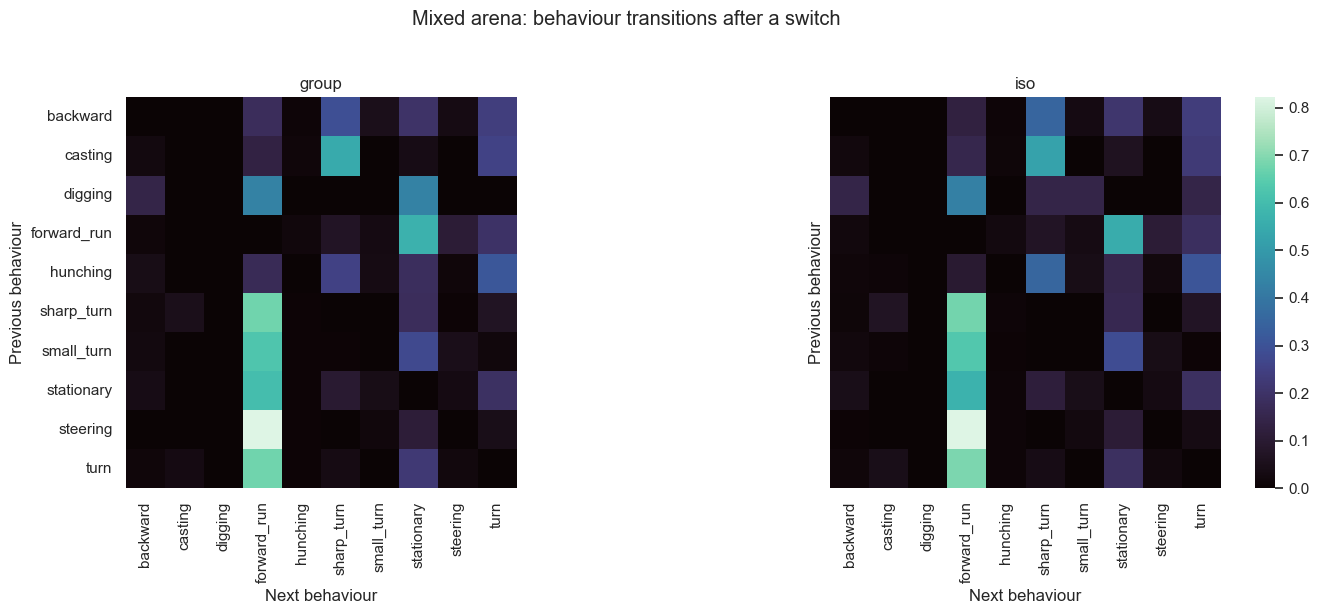

In [23]:
# 23. Mixed experiment: transitions by prior social experience
df_trans_mixed = df_mixed[
    df_mixed['prev_behaviour'].notna() &
    (df_mixed['behaviour'] != df_mixed['prev_behaviour'])
].copy()

all_behaviours_mixed = sorted(set(df_trans_mixed['prev_behaviour']).union(set(df_trans_mixed['behaviour'])))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

transition_mats_mixed = {}
for ax, social_experience in zip(axes, social_order):
    mat = pd.crosstab(
        df_trans_mixed.loc[df_trans_mixed['social_experience'] == social_experience, 'prev_behaviour'],
        df_trans_mixed.loc[df_trans_mixed['social_experience'] == social_experience, 'behaviour'],
        normalize='index'
    )
    mat = mat.reindex(index=all_behaviours_mixed, columns=all_behaviours_mixed).fillna(0)
    transition_mats_mixed[social_experience] = mat

    sns.heatmap(
        mat,
        ax=ax,
        cmap='mako',
        vmin=0,
        vmax=max(0.01, mat.to_numpy().max()),
        square=True,
        cbar=ax == axes[-1]
    )
    ax.set_title(social_experience)
    ax.set_xlabel('Next behaviour')
    ax.set_ylabel('Previous behaviour')

plt.suptitle('Mixed arena: behaviour transitions after a switch', y=1.02)
plt.tight_layout()
plt.show()

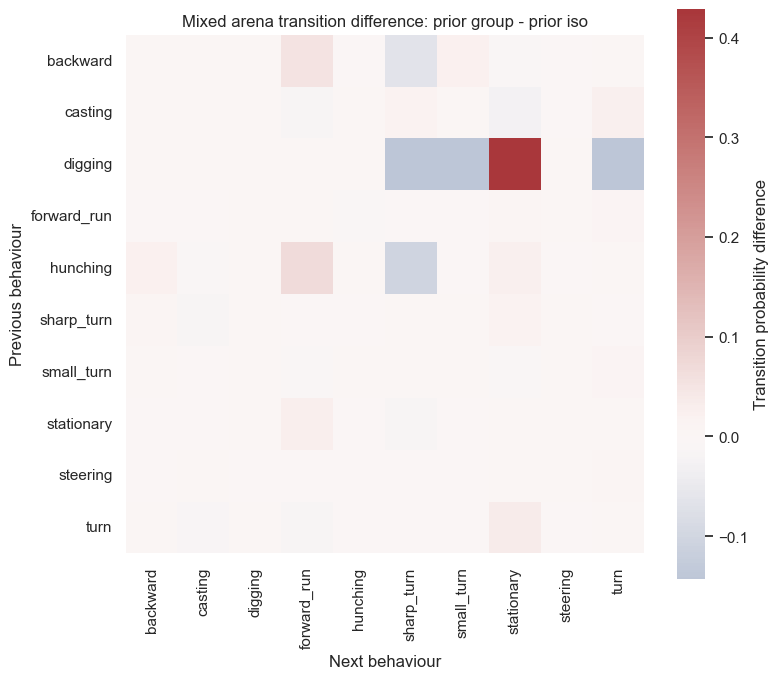

In [24]:
# 24. Mixed experiment transition difference: prior group minus prior iso
transition_difference_mixed = transition_mats_mixed['group'] - transition_mats_mixed['iso']

plt.figure(figsize=(8, 7))
sns.heatmap(
    transition_difference_mixed,
    cmap='vlag',
    center=0,
    square=True,
    cbar_kws={'label': 'Transition probability difference'}
)
plt.xlabel('Next behaviour')
plt.ylabel('Previous behaviour')
plt.title('Mixed arena transition difference: prior group - prior iso')
plt.tight_layout()
plt.show()

In [25]:
# 25. Quick numeric summaries to inspect under the plots
summary_frames_condition = (
    behaviour_prop_condition
    .groupby(['condition', 'behaviour'])['proportion_of_frames']
    .agg(['mean', 'sem'])
    .reset_index()
)

summary_inits_condition = (
    initiation_rate_condition
    .groupby(['condition', 'behaviour'])['initiations_per_1000_frames']
    .agg(['mean', 'sem'])
    .reset_index()
)

summary_bouts_condition = (
    bouts_condition
    .groupby(['condition', 'behaviour'])['n_frames']
    .agg(['median', 'mean'])
    .reset_index()
)

print('Frame proportion summary')
display(summary_frames_condition)

print('Initiation rate summary')
display(summary_inits_condition)

print('Bout length summary, in frames')
display(summary_bouts_condition)

Frame proportion summary


,condition,behaviour,mean,sem
0,grouped,backward,0.006416,0.000310
1,grouped,casting,0.002155,0.000155
2,grouped,digging,0.023439,0.005998
3,grouped,forward_run,0.698583,0.007696
4,grouped,hunching,0.002217,0.000181
5,grouped,sharp_turn,0.041780,0.001333
6,grouped,small_turn,0.005838,0.000204
7,grouped,stationary,0.149424,0.005271
8,grouped,steering,0.013067,0.000472
9,grouped,turn,0.057082,0.001309


Initiation rate summary


,condition,behaviour,mean,sem
0,grouped,backward,4.881026,0.226081
1,grouped,casting,1.974388,0.137730
2,grouped,digging,0.072222,0.018358
3,grouped,forward_run,89.734228,1.446760
4,grouped,hunching,2.019303,0.153388
5,grouped,sharp_turn,15.870825,0.508489
6,grouped,small_turn,5.615301,0.193557
7,grouped,stationary,68.107800,1.612061
8,grouped,steering,12.736048,0.463976
9,grouped,turn,33.123839,0.718398


Bout length summary, in frames


,condition,behaviour,median,mean
0,grouped,backward,1.0,1.314351
1,grouped,casting,1.0,1.091549
2,grouped,digging,264.0,324.538462
3,grouped,forward_run,4.0,7.785699
4,grouped,hunching,1.0,1.097931
5,grouped,sharp_turn,2.0,2.630142
6,grouped,small_turn,1.0,1.039643
7,grouped,stationary,1.0,2.188735
8,grouped,steering,1.0,1.025988
9,grouped,turn,1.0,1.718630
